In [1]:
%cd ..
%load_ext autoreload
%autoreload 2

/nfs/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation


/home/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# Function Encoding

This notebook shows how to encode a function ad a QTT using TTI. This method gives a constant time and constant error regardless the discretization


In [2]:
import torch as tn
import torchtt as tntt
import numpy as np
import matplotlib.pyplot as plt
from src.qtt_interpolation.utils import *
#from src.qtt_interpolation.int_tools import *
import teneva as ten

In [12]:
def ind_to_r(I, a=0, b=1, d=1, pdp=1):
    """
    This function maps a multi-digit index to a real number in [a, b)^d.
    Each entry in I[k] is an integer in 0,...,2**pdp-1 and is expanded to its binary representation.
    The resulting binary digits are concatenated to form a long vector of 0's and 1's for each sample.
    Returns a list of size d.
    """
    # I: shape (num_samples, d), each entry in 0,...,2**pdp-1
    num_samples = I.shape[0]
    l = I.shape[1] * pdp  # total number of binary digits per sample
    # Convert each entry to binary and concatenate
    I_bin = ((I.unsqueeze(-1) >> tn.arange(pdp-1, -1, -1)) & 1).reshape(num_samples, -1)
    powers = tn.tensor([2**(-i) for i in range(1, l//d+1)],dtype=tn.float64)
    result = []
    for j in range(d):
        idx = tn.arange(j, l, d)
        group = I_bin[:, idx]
        wI = group * powers
        x = (b - a) * wI.sum(axis=1) + a
        result.append(x)
    return result



def s4dnu(x, x0= 0.4, y0 = 0.5,s = 0.6, t = 0.25):

    xn = x/s - x0
    y = tn.where((xn >= 0) & (xn <= 1),y0 + 5*t*(0.2969*tn.sqrt(xn)-0.126*xn-0.3516*xn**2+0.2843*xn**3-0.1015*xn**4),-1)
    return y

def s4dnd(x, x0= 0.4, y0 = 0.5,s = 0.6, t = 0.25):

    xn = x/s - x0

    y = tn.where((xn >= 0) & (xn <= 1),y0-5*t*(0.2969*tn.sqrt(xn)-0.126*xn-0.3516*xn**2+0.2843*xn**3-0.1015*xn**4),-1)
    return y

def circle(x,y):
    """
    This function creates a mask for the points in the grid.
    It returns a boolean tensor where True indicates that the point is inside the unit square.
    """
    r=0.25
    return tn.where((x-0.5)**2 + (y-0.5)**2 <= r**2, 1, 0)

def correlated_gaussian_pdf(x, y, mean=None, corr=None):
    """
    Compute the PDF value of a 2D Gaussian at point (x, y) with given mean and correlation matrix.
    Args:
        x (float or torch.Tensor): x-coordinate(s)
        y (float or torch.Tensor): y-coordinate(s)
        mean (list or None): Mean of the distribution. If None, uses [0, 0].
        corr (2x2 torch.Tensor or None): Correlation matrix. If None, uses identity.
    Returns:
        torch.Tensor: PDF value(s) at (x, y)
    """
    if mean is None:
        mean = tn.zeros(2, dtype=tn.float64)
    if corr is None:
        corr = tn.eye(2,dtype=tn.float64)
    pos = tn.stack([x, y], dim=-1)
    mean = tn.tensor(mean, dtype=pos.dtype, device=pos.device)
    corr_inv = tn.linalg.inv(corr)
    det_corr = tn.linalg.det(corr)
    diff = pos - mean
    exponent = -0.5 * tn.sum(diff @ corr_inv * diff, dim=-1)
    norm = 1.0 / (2 * tn.pi * tn.sqrt(det_corr))
    return norm * tn.exp(exponent)

def circles(x,y,alpha=100):
    """
    This function creates a mask for the points in the grid.
    It returns a boolean tensor where True indicates that the point is inside the unit square.
    """
    r=0.25
    return tn.where((x-0.5)**2 + (y-0.5)**2 <= r**2, 1, tn.exp(-alpha*( (x-0.5)**2 + (y-0.5)**2 - r**2) ))

def wing(x,y):
    return tn.where( (s4dnu(x) >= y) & ( s4dnd(x) <= y), 1, 0)




def ind_to_r_ten(I, a=0, b=1, d=1, pdp=1):
    """
    This function maps a multi-digit index to a real number in [a, b)^d.
    Each entry in I[k] is an integer in 0,...,2**pdp-1 and is expanded to its binary representation.
    The resulting binary digits are concatenated to form a long vector of 0's and 1's for each sample.
    Returns a numpy array of shape (num_samples, d).
    """
    I = np.asarray(I)
    num_samples = I.shape[0]
    l = I.shape[1]*pdp  # total number of binary digits per sample
    # Convert each entry to binary and concatenate
    I_bin = ((I[..., None] >> np.arange(pdp-1, -1, -1)) & 1).reshape(num_samples, -1)
    powers = np.array([2**(-i) for i in range(1, l//d+1)])
    result = np.empty((num_samples, d))
    for j in range(d):
        idx = np.arange(j, l, d)
        group = I_bin[:, idx]
        wI = group * powers
        x = (b - a) * wI.sum(axis=1) + a
        result[:, j] = x
    return result

def circle_ten(X):
    """
    This function creates a mask for the points in the grid.
    It returns a boolean tensor where True indicates that the point is inside the unit square.
    """
    r=0.125
    x, y = X[:, 0], X[:, 1]
    return np.where((x-0.5)**2 + (y-0.5)**2 <= r**2, 1, np.exp(-100*( (x-0.5)**2 + (y-0.5)**2 - r**2) ))

def correlated_gaussian_pdf_ten(X, mean=None, corr=None):
    """
    Compute the PDF value of a 2D Gaussian at points X with given mean and correlation matrix.
    Args:
        X (np.ndarray): shape (num_samples, 2), each row is a point [x, y]
        mean (list or None): Mean of the distribution. If None, uses [0, 0].
        corr (2x2 np.ndarray or None): Correlation matrix. If None, uses identity.
    Returns:
        np.ndarray: PDF value(s) at each row of X
    """
    X = np.asarray(X)
    if mean is None:
        mean = [0.0, 0.0]
    if corr is None:
        corr = np.eye(2)
    mean = np.array(mean, dtype=X.dtype)
    corr_inv = np.linalg.inv(corr)
    det_corr = np.linalg.det(corr)
    diff = X - mean
    exponent = -0.5 * np.sum(diff @ corr_inv * diff, axis=1)
    norm = 1.0 / (2 * np.pi * np.sqrt(det_corr))
    return norm * np.exp(exponent)


corr_medium_n = np.array([[1.0, 0.5],
                         [0.5, 1.0]]) 

## circle mask

#### trochtt

In [4]:

base = 2
p = 7
N = [base,base]*p
mps = tntt.interpolate.dmrg_cross( lambda I: circles(*ind_to_r(I,d=2,pdp=1)) , N, eps = 1e-8,kick=1,rmax=30,nswp=30)
mps

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 3, 5, 9, 17, 30, 31, 31, 31, 31, 16, 8, 4, 2, 1]

Device: cpu, dtype: torch.float64
#entries 10410 compression 0.6353759765625

In [5]:

base = 2
p = 8
N = [base**2]*p
mps = tntt.interpolate.dmrg_cross( lambda I: circles(*ind_to_r(I,d=2,pdp=2)) , N, eps = 1e-8,kick=4,rmax=300,nswp=30).round()
mps

TT with sizes and ranks:
N = [4, 4, 4, 4, 4, 4, 4, 4]
R = [1, 4, 16, 54, 75, 64, 16, 4, 1]

Device: cpu, dtype: torch.float64
#entries 43496 compression 0.6636962890625

#### teneva

In [4]:
#coarse
p = 9
n = [ 2,2]*p   # Shape of the tensor
def func(I):
    X = ind_to_r_ten(I,a=0,b=1,d=2,pdp=1)
    return circle_ten(X)

m         = None  # Number of calls to target function
e         =  1e-10  # Desired accuracy
nswp      = 3   # Sweep number
r         = 30      # TT-rank of the initial tensor
dr_min    = 2      # Cross parameter (minimum number of added rows")
dr_max    = 5    # Cross parameter (maximum number of added rows)
info, cache = {}, {}
Y = ten.rand(n, r)
Y = ten.cross(func, Y, m, e, nswp, dr_min=dr_min, dr_max=dr_max,
    info=info,log=True,cache=cache,m_cache_scale=10)
Yr = ten.truncate(Y, 1e-15) # We round the result at the end



print(f'Evals func           : {info["m"]:-10d}')
print(f'Cache uses           : {info["m_cache"]:-10d}')
print(f'Iter accuracy        : {info["e"]:-10.2e}')
print(f'Sweep number         : {info["nswp"]:-10d}')
print(f'Stop condition       : {info["stop"]:>10}')
print(f'TT-rank of pure res  : {info["r"]:-10.1f}')
print(f'TT-rank of trunc res : {ten.erank(Yr):-10.1f}')


# pre | time:      0.013 | evals: 0.00e+00 (+ 0.00e+00) | rank:  30.0 | 
#   1 | time:      2.250 | evals: 1.65e+04 (+ 2.53e+04) | rank:  28.5 | e: 1.0e+00 | 
#   1 | time:      2.250 | evals: 1.65e+04 (+ 2.53e+04) | rank:  28.5 | e: 1.0e+00 | 
#   2 | time:      5.741 | evals: 2.58e+04 (+ 7.62e+04) | rank:  33.6 | e: 5.9e-03 | 
#   2 | time:      5.741 | evals: 2.58e+04 (+ 7.62e+04) | rank:  33.6 | e: 5.9e-03 | 
#   3 | time:     11.233 | evals: 3.65e+04 (+ 1.47e+05) | rank:  38.6 | e: 5.5e-04 | stop: nswp | 
Evals func           :      36463
Cache uses           :     147209
Iter accuracy        :   5.50e-04
Sweep number         :          3
Stop condition       :       nswp
TT-rank of pure res  :       38.6
TT-rank of trunc res :       38.1
#   3 | time:     11.233 | evals: 3.65e+04 (+ 1.47e+05) | rank:  38.6 | e: 5.5e-04 | stop: nswp | 
Evals func           :      36463
Cache uses           :     147209
Iter accuracy        :   5.50e-04
Sweep number         :          3
Stop condit

In [22]:
ccores = [tn.tensor(c,dtype=tn.float64) for c in Yr]
mpscircles = tntt.reshape(tntt.TT(ccores),[4]*p)

num_points = 2**p
l = 1
x = tn.linspace(0, l, num_points + 1, dtype=tn.float64)[:-1]
y = tn.linspace(0, l, num_points + 1, dtype=tn.float64)[:-1]
bx = circles(tn.full_like(y,l), y)
#bx = tntt.TT(bx,[2]*p)
by = circles(x, tn.full_like(x, l))
#by = tntt.TT(by,[2]*p)
f11 = circles(*tn.ones(2)).item()
fboundary = bx,by

pfinal = 12
circle_TTI = skcubic_i(mpscircles,pfinal,fboundary, eps=1e-5, order=1)

/tmp/ipykernel_2998347/289526910.py:80: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bx = tntt.TT(tn.tensor(f_boundary[0],dtype=tn.float64),[2]*ni,eps=eps)
/tmp/ipykernel_2998347/289526910.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  by = tntt.TT( tn.tensor(f_boundary[1],dtype=tn.float64),[2]*ni,eps=eps)


In [11]:
def d_coeff_mat(M, order=0):
    if order == 0:
        return M
    elif order == 1:
        return M[:, 1:] * tn.tensor([1, 2, 3], dtype=M.dtype)
    elif order == 2:
        return M[:, 2:] * tn.tensor([2, 6], dtype=M.dtype)
    else:
        raise ValueError("Only derivative orders 0, 1, and 2 are supported.")
    
def qtt_skcubic2d_p(mps, fscale, eps = 1e-15, order = 1, p_derivative = [0,0]):


    ni = len(mps.N)//2
    nc = fscale - ni 

    id0 = I_qtt(ni)
    ones = tntt.ones([2,2]*ni)
    onesf = tntt.ones([2]*nc)

    if order == 1:
        # Build Kernel interpolant
        Mkc = tn.tensor([
            [0, 2, 0, 0],
            [-1, 0, 1, 0],
            [2, -5, 4, -1],
            [-1, 3, -3, 1]
        ], dtype=tn.float64) /2
        Mkct = Mkc.t()

    elif order == 2:
        Mkct = tn.tensor([
            [1, -3, 3, -1],
            [4, 0, -6, 3],
            [1, 3, 3, -3],
            [0,0, 0, 1]
        ], dtype=tn.float64) /6

    sm10 = P_qtt( 2**ni -1, ni)
    O20 = P_qtt( 2**ni -2, ni)
    Om10 = P_qtt( 1, ni)


    Mx = d_coeff_mat(Mkct, p_derivative[0]) 
    My = d_coeff_mat(Mkct, p_derivative[1])
    print(Mx)
    polsx = [tntt.kron( ones, zukron(tntt.TT(qtt_polynomial_cores(Mx[i], nc)) , onesf) ).round(eps) for i in range(4)]
    polsy = [tntt.kron( ones, zukron( onesf , tntt.TT( qtt_polynomial_cores(My[i], nc)) )).round(eps) for i in range(4)]

    
    zones2 = zukron(onesf, onesf)

    oneso = tntt.eye([2]*nc)
    id = tntt.kron(id0,oneso)
    sm1 = tntt.kron(sm10,oneso)
    Om1 = tntt.kron(Om10,oneso)
    O2 = tntt.kron(O20,oneso)

    mps = tntt.kron(mps, zones2 )
    print((zukron(id,Om1) @ mps) )
    print(polsy[0])
    print((zukron(id,Om1) @ mps) * ( polsy[0] ))
    #interpolate y,
    f_ky = (zukron(id,Om1) @ mps) * ( polsy[0] ) + ( mps * polsy[1] ) + ( zukron(id,sm1) @ mps ) * (polsy[2]) + ( zukron(id,O2) @ mps ) * (polsy[3]) 
    f_ky = f_ky.round(eps)

    #interpolate x
    f_kxy =  (zukron(Om1,id) @ f_ky) *( polsx[0] ) + ( f_ky *  polsx[1] ) + ( zukron(sm1,id) @ f_ky ) * (polsx[2]) +  ( zukron(O2,id) @ f_ky ) * ( polsx[3])
    f_kxy = f_kxy.round(eps)

    return f_kxy

In [12]:
ccores = [tn.tensor(c,dtype=tn.float64) for c in Yr]
mpscircles = tntt.TT(ccores)

#num_points = 2**p
#l = 1
#x = tn.linspace(0, l, num_points + 1, dtype=tn.float64)[:-1]
#y = tn.linspace(0, l, num_points + 1, dtype=tn.float64)[:-1]
#bx = circles(tn.full_like(y,l), y)
#bx = tntt.TT(bx,[2]*p)
#by = circles(x, tn.full_like(x, l))
#by = tntt.TT(by,[2]*p)
#f11 = circles(*tn.ones(2)).item()
#fboundary = [bx,by,f11]

pfinal = 12
circle_TTI = qtt_skcubic2d_p(mpscircles,pfinal, eps=1e-8, order=1)

circle_tti = [c.numpy() for c in circle_TTI.cores]

tensor([[ 0.0000, -0.5000,  1.0000, -0.5000],
        [ 1.0000,  0.0000, -2.5000,  1.5000],
        [ 0.0000,  0.5000,  2.0000, -1.5000],
        [ 0.0000,  0.0000, -0.5000,  0.5000]], dtype=torch.float64)
TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 8, 16, 32, 64, 100, 108, 116, 120, 112, 104, 114, 64, 32, 16, 8, 4, 1, 1, 1, 1, 1, 1, 1]

Device: cpu, dtype: torch.float64
#entries 186648 compression 0.01112508773803711

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 1]

Device: cpu, dtype: torch.float64
#entries 70 compression 4.172325134277344e-06

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 8, 16, 32, 64, 100, 108, 116, 120, 112, 104, 114, 64, 32, 16, 8, 4, 1, 1, 2, 2, 2, 2, 1]

Device: cpu, dtype: torch.float64
#entrie

In [14]:
#fine

#coarse
p = pfinal
n = [ 2,2]*p   # Shape of the tensor
def func(I):
    X = ind_to_r_ten(I,a=0,b=1,d=2,pdp=1)
    return circle_ten(X)

m         = None  # Number of calls to target function
e         =  1e-10  # Desired accuracy
nswp      = 3   # Sweep number
r         = 40      # TT-rank of the initial tensor
dr_min    = 2      # Cross parameter (minimum number of added rows)
dr_max    = 5    # Cross parameter (maximum number of added rows)
info, cache = {}, {}
Y = ten.rand(n, r)
Y = ten.cross(func, Y, m, e, nswp, dr_min=dr_min, dr_max=dr_max,
    info=info,log=True,cache=cache,m_cache_scale=5)
Yr = ten.truncate(Y, 1e-8) # We round the result at the end



print(f'Evals func           : {info["m"]:-10d}')
print(f'Cache uses           : {info["m_cache"]:-10d}')
print(f'Iter accuracy        : {info["e"]:-10.2e}')
print(f'Sweep number         : {info["nswp"]:-10d}')
print(f'Stop condition       : {info["stop"]:>10}')
print(f'TT-rank of pure res  : {info["r"]:-10.1f}')
print(f'TT-rank of trunc res : {ten.erank(Yr):-10.1f}')


# pre | time:      1.096 | evals: 0.00e+00 (+ 0.00e+00) | rank:  40.0 | 
#   1 | time:      7.773 | evals: 4.81e+04 (+ 6.37e+04) | rank:  39.2 | e: 1.0e+00 | 
#   1 | time:      7.773 | evals: 4.81e+04 (+ 6.37e+04) | rank:  39.2 | e: 1.0e+00 | 
#   2 | time:     19.189 | evals: 8.25e+04 (+ 1.87e+05) | rank:  46.0 | e: 2.4e-03 | 
#   2 | time:     19.189 | evals: 8.25e+04 (+ 1.87e+05) | rank:  46.0 | e: 2.4e-03 | 
#   3 | time:     37.897 | evals: 1.16e+05 (+ 3.66e+05) | rank:  52.5 | e: 1.4e-03 | stop: nswp | 
Evals func           :     115610
Cache uses           :     366114
Iter accuracy        :   1.39e-03
Sweep number         :          3
Stop condition       :       nswp
TT-rank of pure res  :       52.5
TT-rank of trunc res :       48.8
#   3 | time:     37.897 | evals: 1.16e+05 (+ 3.66e+05) | rank:  52.5 | e: 1.4e-03 | stop: nswp | 
Evals func           :     115610
Cache uses           :     366114
Iter accuracy        :   1.39e-03
Sweep number         :          3
Stop condit

In [10]:
n = [ 2,2]*pfinal
# Number of test points:
m_tst = int(2.E+4)
# Random multi-indices for the test points:
I_tst = np.vstack([np.random.choice(k, m_tst) for k in n]).T
# Function values for the test points:
y_tst = func(I_tst)
norm = np.linalg.norm(y_tst)

# Compute approximation in test points:
y_tt = ten.get_many(Yr, I_tst)
# Accuracy of the result for test points:
e_tst = np.linalg.norm(y_tt - y_tst) / norm
print(f'Error on test        : {e_tst:-10.2e}')

y_tti = ten.get_many(circle_tti, I_tst)
e_tstti = np.linalg.norm(y_tti - y_tst) / norm
print(f'Error on test        : {e_tstti:-10.2e}')

Error on test        :   1.42e-02
Error on test        :   4.40e-04
Error on test        :   4.40e-04


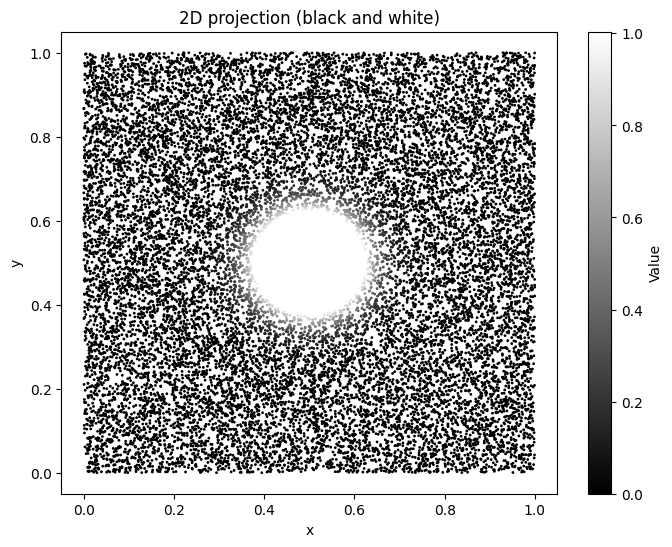

In [50]:
coords, values = ind_to_r_ten(I_tst,a=0,b=1,d=2,pdp=1), y_tti
plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=values, cmap='gray', s=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('2D projection (black and white)')
plt.colorbar(label='Value')
plt.show()

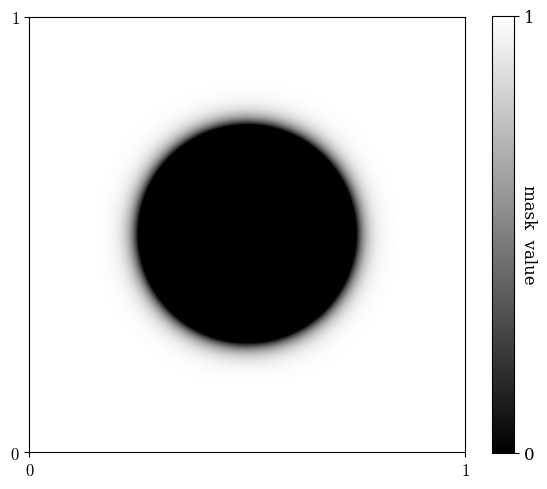

In [15]:
plt.rc('font',      family='serif', size=12)
plt.rc('mathtext', fontset='cm')

p = 10
nx, ny = 2**p, 2**p
xs = tn.linspace(0, 1, nx+1, dtype=tn.float64)[:-1]
ys = tn.linspace(0, 1, ny+1, dtype=tn.float64)[:-1]
X, Y = tn.meshgrid(xs, ys, indexing="xy")
Z   = 1-circles(X, Y,alpha=100)

# ─── Plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(Z,
               origin="lower",
               extent=[0,1,0,1],
               aspect="equal",
               cmap="gray")

# colorbar with 3 ticks and mathtext label
cbar = fig.colorbar(im, ax=ax)
cbar.set_ticks([0, 1])
cbar.set_label(r'mask  value',
               rotation=270,
               labelpad=2,
               fontsize=12)

# exactly two ticks on each axis
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels([r'$0$', r'$1$'], fontsize=12)
ax.set_yticklabels([r'$0$', r'$1$'], fontsize=12)

# bold mathtext title
#ax.set_title(r'$\mathbf{Wing\ Bump\ Heatmap}$', pad=0, fontsize=16)

plt.tight_layout()
fig.savefig('./metrics/figures/circle.png', dpi=150, bbox_inches='tight')
plt.show()


## Gaussian

In [4]:
# Create a random 2D correlation matrix
A = tn.randn(2, 2)
cov = A @ A.t()  # Make it symmetric and positive definite
D = tn.diag(1 / tn.sqrt(tn.diag(cov)))
corr = D @ cov @ D  # Normalize to get correlation matrix

# Manually define a medium correlation matrix (e.g., off-diagonal = 0.5)
corr_medium = tn.tensor([[1.0, 0.5],
                         [0.5, 1.0]],dtype=tn.float64)

In [ ]:

base = 2
p = 11
N = [base,base]*p
mps = tntt.interpolate.dmrg_cross( lambda I: correlated_gaussian_pdf(*ind_to_r(I,a=-3,b=3,d=2,pdp=1),corr=corr_medium ) , N, eps = 1e-14,kick=1,nswp=30).round()
mps

C:\Users\siddhartha.morales\AppData\Local\Temp\ipykernel_26080\786237135.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = tn.tensor(mean, dtype=pos.dtype, device=pos.device)


TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 4, 8, 16, 32, 61, 59, 52, 45, 38, 33, 29, 26, 23, 20, 18, 15, 13, 8, 4, 2, 1]

Device: cpu, dtype: torch.float64
#entries 36690 compression 0.008747577667236328

In [5]:
# Create a 2D grid from -3 to 3 (not including endpoints) with 2**8 points per dimension
p=10
num_points = 2**p
l = 5
x = tn.linspace(-l, l, num_points + 1, dtype=tn.float64)[:-1]
y = tn.linspace(-l, l, num_points + 1, dtype=tn.float64)[:-1]
X, Y = tn.meshgrid(x, y, indexing='ij')

# Evaluate the correlated Gaussian PDF on the grid
pdf_grid = correlated_gaussian_pdf(X, Y, mean=[0, 0], corr=corr_medium)

gauss_svd = tntt.TT(zM(pdf_grid,p),[2,2]*p,eps=1e-14)
gauss_svd.round(1e-14)

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 4, 8, 16, 32, 61, 87, 91, 75, 63, 54, 46, 40, 34, 25, 16, 8, 4, 2, 1]

Device: cpu, dtype: torch.float64
#entries 75828 compression 0.07231521606445312

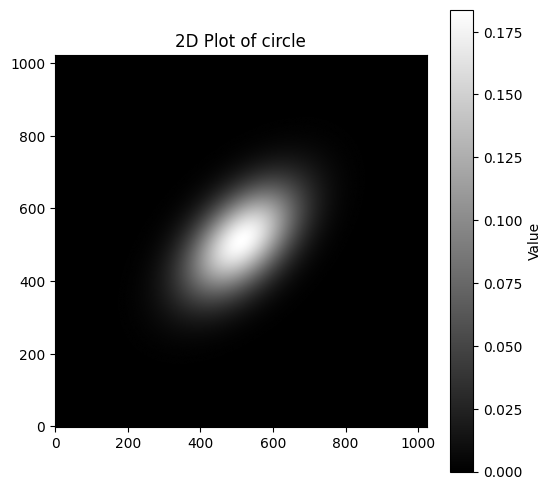

In [6]:
ttmask = z_order_to_normal_torch(gauss_svd.full().flatten(), 2**p, 2**p).t().cpu().numpy()
plt.figure(figsize=(6, 6))
plt.imshow(ttmask, cmap='gray', origin='lower')
plt.colorbar(label='Value')
plt.title('2D Plot of circle')
plt.show()

In [7]:
def skcubic_i(mps, fscale, f_boundary, eps = 1e-15,epsilon = 0.1 , order = 1, boundary = 'lineare'):

    if not isinstance(f_boundary, tuple):
        f_boundary = [f_boundary, None]

    ni = len(mps.N)
    nc = fscale - ni 

    id0 = I_qtt(ni)
    sm10 = R_qtt( 2**ni -1, ni)
    sm20 = R_qtt( 2**ni -2, ni)
    smm10 = L_qtt( 1, ni)
    ones = tntt.ones([1]*ni)
    onesf = tntt.ones([2]*nc)
    delta = dmps(2**ni -1,ni)
    deltae = tntt.kron(delta,onesf)

    if order == 1:
        # Build Kernel interpolant
        Mkc = tn.tensor([
            [0, 2, 0, 0],
            [-1, 0, 1, 0],
            [2, -5, 4, -1],
            [-1, 3, -3, 1]
        ], dtype=tn.float64) /2

        Mkct = Mkc.t()

        Om10 = smm10 + 3*dmpo(0,0,ni) - 3*dmpo(0,1,ni) + dmpo(0,2,ni) 
        O20 = sm20 - 3*dmpo(2**ni-1,2**ni-1,ni) + dmpo(2**ni-1,2**ni-2,ni)
        delta2 = dmps(2**ni -2,ni) + 3*dmps(2**ni -1,ni)
        delta2e = tntt.kron(delta2,onesf)
    elif order == 2:

        Mkct = tn.tensor([
            [1, -3, 3, -1],
            [4, 0, -6, 3],
            [1, 3, 3, -3],
            [0,0, 0, 1]
        ], dtype=tn.float64) /6

        Om10 = smm10 + 3*dmpo(0,0,ni) - 3*dmpo(0,1,ni) + dmpo(0,2,ni) 
        O20 = sm20 - 3*dmpo(2**ni-1,2**ni-1,ni) + dmpo(2**ni-1,2**ni-2,ni)
        delta2 = dmps(2**ni -2,ni) + 3*dmps(2**ni -1,ni)
        delta2e = tntt.kron(delta2,onesf)
    
        if boundary == 'lineare':
            Om10 = smm10 + 2*dmpo(0,0,ni) - dmpo(0,1,ni) 
            O20 = sm20 - dmpo(2**ni-1,2**ni-1,ni) 
            delta2 = dmps(2**ni -2,ni) + 2*dmps(2**ni -1,ni)
        elif boundary == 'mirror':
            Om10 = smm10 +  dmpo(0,1,ni) 
            O20 = sm20 + dmpo(2**ni-1,2**ni-1,ni) 
            delta2 = dmps(2**ni -2,ni) 
        elif boundary == 'clamped':
            Om10 = smm10 +  dmpo(0,0,ni) 
            O20 = sm20 
            delta2 = dmps(2**ni -2,ni) + dmps(2**ni -1,ni)

    if type(f_boundary[0]) is str:
        if f_boundary[0] == 'gaussian':
            scale = ni
            base_scaling = 2.0 ** (-4.0 / 3.0)
            r = 10
            f11 = 1 + (base_scaling**scale) * epsilon * np.random.randn()
            bx = (1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1]) ) * (1-delta) + f11*delta
            by = (1 + (base_scaling**scale) * epsilon * tntt.randn([2]*ni, [1]+[r]*(ni-1)+[1])) * (1-delta) + f11*delta
            corner = f11*delta
            corner2 = f11*delta2
        
        elif f_boundary[0] == 'zero':
            f11 = 0
            bx = tntt.zeros([2]*ni)
            by = tntt.zeros([2]*ni)
            corner = f11*delta
            corner2 = f11*delta2

    else:
        f11 = f_boundary[0][-1]
        bx = tntt.TT(tn.tensor(f_boundary[0],dtype=tn.float64),[2]*ni,eps=eps)
        by = tntt.TT( tn.tensor(f_boundary[1],dtype=tn.float64),[2]*ni,eps=eps)
        corner = f11*delta
        corner2 = f11*delta2

    mbx = zkron( delta , bx )
    mbx2 = zkron( delta2 , bx )

    pols = [tntt.TT(qtt_polynomial_cores(Mkct[i], nc)) for i in range(4)]
    polsx = [tntt.kron( ones, zkron(tntt.TT(qtt_polynomial_cores(Mkct[i], nc)) , onesf) ).round(eps) for i in range(4)]
    polsy = [tntt.kron( ones, zkron( onesf , tntt.TT( qtt_polynomial_cores(Mkct[i], nc)) ) ).round(eps) for i in range(4)]
    
    zones = zkron(onesf, onesf)
    mps = tntt.kron(mps, zones )
    mbx = tntt.kron(mbx, zones )
    mbx2 = tntt.kron(mbx2,zones )

    oneso = tntt.eye([2]*nc)
    id = tntt.kron(id0,oneso)
    sm1 = tntt.kron(sm10,oneso)
    Om1 = tntt.kron(Om10,oneso)
    O2 = tntt.kron(O20,oneso)

    f_kx =  (zkron(Om1,id) @ mps) *( polsx[0] ) + ( mps *  polsx[1] ) + ( zkron(sm1,id) @ mps + mbx) * (polsx[2]) +  ( zkron(O2,id) @ mps + mbx2) * ( polsx[3])
    f_kx = f_kx.round(eps)

    By = tntt.kron( ( Om10 @ by) , pols[0] ) + tntt.kron( by , pols[1] ) +  tntt.kron( sm10 @ by + corner, pols[2]) +  tntt.kron( O20 @ by + corner2 ,  pols[3])
    By = By.round(eps)
    mby = zkron( By , deltae )
    mby2 = zkron( By , delta2e )
    
    f_kcs = (zkron(id,Om1) @ f_kx) * ( polsy[0] ) + ( f_kx * polsy[1] ) + ( zkron(id,sm1) @ f_kx + mby) * (polsy[2]) + ( zkron(id,O2) @ f_kx + mby2) * (polsy[3]) 
    f_kcs = f_kcs.round(eps)

    return f_kcs

In [ ]:
l=5
x = tn.linspace(-l, l, num_points + 1, dtype=tn.float64)[:-1]
y = tn.linspace(-l, l, num_points + 1, dtype=tn.float64)[:-1]
X, Y = tn.meshgrid(x, y, indexing='ij')

# Evaluate function at rightmost x=3 (for all y) and y=3 (for all x)
bx = correlated_gaussian_pdf(tn.full_like(y,l), y, mean=[0, 0], corr=corr_medium)
by = correlated_gaussian_pdf(x, tn.full_like(x, l), mean=[0, 0], corr=corr_medium)

f_boundary = bx, by

fscale=18
c_int = skcubic_i(gauss_svd, fscale, f_boundary=f_boundary, eps = 1e-14,epsilon = 0.1 , order = 2, boundary = 'lineare').to_qtt(1e-14)
c_int


In [ ]:
ttmask = z_order_to_normal_torch(c_int.full().flatten(), 2**fscale, 2**fscale).t().cpu().numpy()
plt.figure(figsize=(6, 6))
plt.imshow(ttmask, cmap='gray', origin='lower')
plt.colorbar(label='Value')
plt.title('2D Plot of circle')
plt.show()

### teneva

In [10]:
import teneva as ten

In [11]:
p = 15
n = [ 2,2]*p   # Shape of the tensor
l = 3
def func(I):
    X = ind_to_r_ten(I,a=-l,b=l,d=2,pdp=1)
    return correlated_gaussian_pdf_ten(X,corr=corr_medium_n)

m         = None  # Number of calls to target function
e         =  1e-14   # Desired accuracy
nswp      = None   # Sweep number
r         = 5      # TT-rank of the initial tensor
dr_min    = 2      # Cross parameter (minimum number of added rows)
dr_max    = 5      # Cross parameter (maximum number of added rows)

In [12]:

info, cache = {}, {}
Y = ten.rand(n, r)
Y = ten.cross(func, Y, m, e, nswp, dr_min=dr_min, dr_max=dr_max,
    info=info, cache=cache,log=True)
Yr = ten.truncate(Y, 1e-15) # We round the result at the end



print(f'Evals func           : {info["m"]:-10d}')
print(f'Cache uses           : {info["m_cache"]:-10d}')
print(f'Iter accuracy        : {info["e"]:-10.2e}')
print(f'Sweep number         : {info["nswp"]:-10d}')
print(f'Stop condition       : {info["stop"]:>10}')
print(f'TT-rank of pure res  : {info["r"]:-10.1f}')
print(f'TT-rank of trunc res : {ten.erank(Yr):-10.1f}')


# pre | time:      0.018 | evals: 0.00e+00 (+ 0.00e+00) | rank:   5.0 | 
#   1 | time:      0.080 | evals: 2.34e+03 (+ 2.70e+03) | rank:   8.6 | e: 1.0e+00 | 
#   2 | time:      0.234 | evals: 6.82e+03 (+ 1.09e+04) | rank:  13.1 | e: 5.7e-02 | 
#   2 | time:      0.234 | evals: 6.82e+03 (+ 1.09e+04) | rank:  13.1 | e: 5.7e-02 | 
#   3 | time:      0.996 | evals: 1.70e+04 (+ 2.86e+04) | rank:  19.4 | e: 1.3e-02 | 
#   3 | time:      0.996 | evals: 1.70e+04 (+ 2.86e+04) | rank:  19.4 | e: 1.3e-02 | 
#   4 | time:      3.478 | evals: 3.82e+04 (+ 6.62e+04) | rank:  26.9 | e: 9.0e-05 | 
#   4 | time:      3.478 | evals: 3.82e+04 (+ 6.62e+04) | rank:  26.9 | e: 9.0e-05 | 
#   5 | time:      9.825 | evals: 7.72e+04 (+ 1.33e+05) | rank:  34.8 | e: 7.8e-07 | 
#   5 | time:      9.825 | evals: 7.72e+04 (+ 1.33e+05) | rank:  34.8 | e: 7.8e-07 | 
#   6 | time:     20.424 | evals: 1.42e+05 (+ 2.35e+05) | rank:  42.6 | e: 0.0e+00 | stop: e | 
Evals func           :     142115
Cache uses           : 

In [14]:
def func4(I):
    X = ind_to_r_ten(I,a=-l,b=l,d=2,pdp=2)
    return correlated_gaussian_pdf_ten(X,corr=corr_medium_n)


p_coarse = 11
e=1e-14
ncoarse = [ 2,2]*p_coarse
Yc = ten.rand(ncoarse, r)
cache = {}
Yc = ten.cross(func, Yc, m, e, nswp, dr_min=dr_min, dr_max=dr_max,log=True,cache=cache)

Yc = ten.qtt_to_tt(Yc,2)



# pre | time:      0.009 | evals: 0.00e+00 (+ 0.00e+00) | rank:   5.0 | 
#   1 | time:      0.048 | evals: 1.60e+03 (+ 1.90e+03) | rank:   8.4 | e: 1.0e+00 | 
#   2 | time:      0.122 | evals: 4.37e+03 (+ 7.60e+03) | rank:  12.5 | e: 5.6e-02 | 
#   3 | time:      0.500 | evals: 1.08e+04 (+ 1.98e+04) | rank:  18.8 | e: 1.3e-02 | 
#   3 | time:      0.500 | evals: 1.08e+04 (+ 1.98e+04) | rank:  18.8 | e: 1.3e-02 | 
#   4 | time:      2.221 | evals: 2.36e+04 (+ 4.56e+04) | rank:  25.6 | e: 1.7e-04 | 
#   4 | time:      2.221 | evals: 2.36e+04 (+ 4.56e+04) | rank:  25.6 | e: 1.7e-04 | 
#   5 | time:      6.047 | evals: 4.50e+04 (+ 9.20e+04) | rank:  32.8 | e: 8.8e-07 | 
#   5 | time:      6.047 | evals: 4.50e+04 (+ 9.20e+04) | rank:  32.8 | e: 8.8e-07 | 
#   6 | time:     12.955 | evals: 7.85e+04 (+ 1.63e+05) | rank:  39.6 | e: 4.7e-08 | 
#   6 | time:     12.955 | evals: 7.85e+04 (+ 1.63e+05) | rank:  39.6 | e: 4.7e-08 | 
#   7 | time:     24.335 | evals: 1.25e+05 (+ 2.63e+05) | rank:  46

In [15]:
num_points = 2**p_coarse
x = tn.linspace(-l, l, num_points + 1, dtype=tn.float64)[:-1] 
y = tn.linspace(-l, l, num_points + 1, dtype=tn.float64)[:-1]

# Evaluate function at rightmost x=3 (for all y) and y=3 (for all x)
bx = correlated_gaussian_pdf(tn.full_like(y,l), y, corr=corr_medium)
by = correlated_gaussian_pdf(x, tn.full_like(x, l), corr=corr_medium)

f_boundary = bx, by

c_int = skcubic_i(tntt.TT([tn.tensor(a,dtype=tn.float64) for a in Yc],1e-14), fscale=18, f_boundary=f_boundary, eps=1e-14, order=1, boundary='lineare').to_qtt(1e-14)
gauss_int = [c.numpy() for c in c_int.cores]

/tmp/ipykernel_2998347/786237135.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = tn.tensor(mean, dtype=pos.dtype, device=pos.device)
/tmp/ipykernel_2998347/289526910.py:80: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bx = tntt.TT(tn.tensor(f_boundary[0],dtype=tn.float64),[2]*ni,eps=eps)
/tmp/ipykernel_2998347/289526910.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  by = tntt.TT( tn.tensor(f_boundary[1],dtype=tn.float64),[2]*ni,eps=eps)


In [16]:
ten.show(Yr),ten.show(gauss_int)

TT-tensor    30D : |2| |2| |2| |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2| |2| |2| |2|
<rank>  =   41.6 :   \2/ \4/ \8/ \16/ \32/ \58/ \52/ \49/ \50/ \50/ \49/ \48/ \47/ \47/ \47/ \47/ \47/ \48/ \49/ \50/ \50/ \51/ \51/ \51/ \32/ \16/ \8/ \4/ \2/
TT-tensor    36D : |2| |2| |2| |2|  |2|  |2|  |2|   |2|  |2|   |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2| |2| |2| |2|
<rank>  =   44.6 :   \2/ \4/ \8/ \16/ \32/ \64/ \114/ \80/ \124/ \62/ \98/ \49/ \76/ \38/ \64/ \32/ \56/ \28/ \36/ \18/ \28/ \16/ \22/ \16/ \26/ \15/ \25/ \13/ \20/ \10/ \17/ \10/ \8/ \4/ \2/


(None, None)

In [17]:
# Number of test points:
m_tst = int(1.E+4)
# Random multi-indices for the test points:
I_tst = np.vstack([np.random.choice(k, m_tst) for k in n]).T
# Function values for the test points:
y_tst = func(I_tst)
norm = np.linalg.norm(y_tst)

# Compute approximation in test points:
y_tt = ten.get_many(Yr, I_tst)
# Accuracy of the result for test points:
e_tst = np.linalg.norm(y_tt - y_tst) / norm
print(f'Error on test        : {e_tst:-10.2e}')

y_tti = ten.get_many(gauss_int, I_tst)
e_tstti = np.linalg.norm(y_tti - y_tst) / norm


print(f'Error on test        : {e_tstti:-10.2e}')

Error on test        :   3.89e-09
Error on test        :   7.00e+00
Error on test        :   7.00e+00


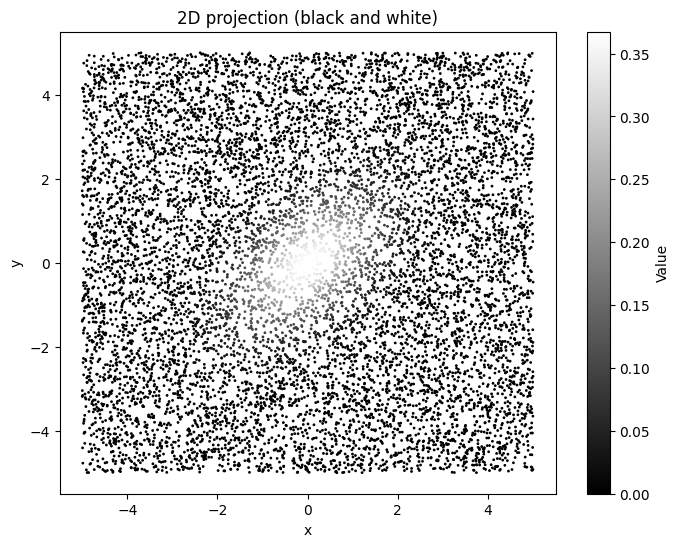

In [ ]:
coords, values = ind_to_r_ten(I_tst,a=-l,b=l,d=2,pdp=1), y_tti
plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=values, cmap='gray', s=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('2D projection (black and white)')
plt.colorbar(label='Value')
plt.show()


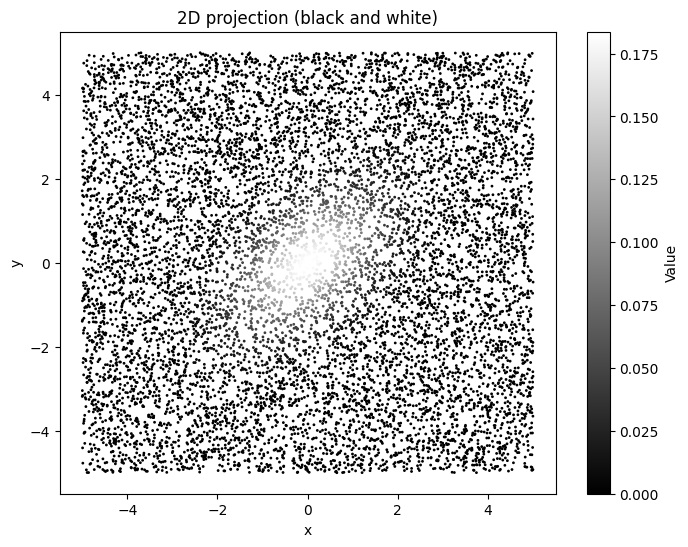

In [ ]:
coords, values = ind_to_r_ten(I_tst,a=-l,b=l,d=2,pdp=1), y_tt
plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=values, cmap='gray', s=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('2D projection (black and white)')
plt.colorbar(label='Value')
plt.show()

## 2d Mask

In [ ]:
# Updated import after merging tutils into utils
from src.qtt_interpolation.utils import *